In [1]:
import nonlinear_benchmarks as nlb
from matplotlib import pyplot as plt
import numpy as np

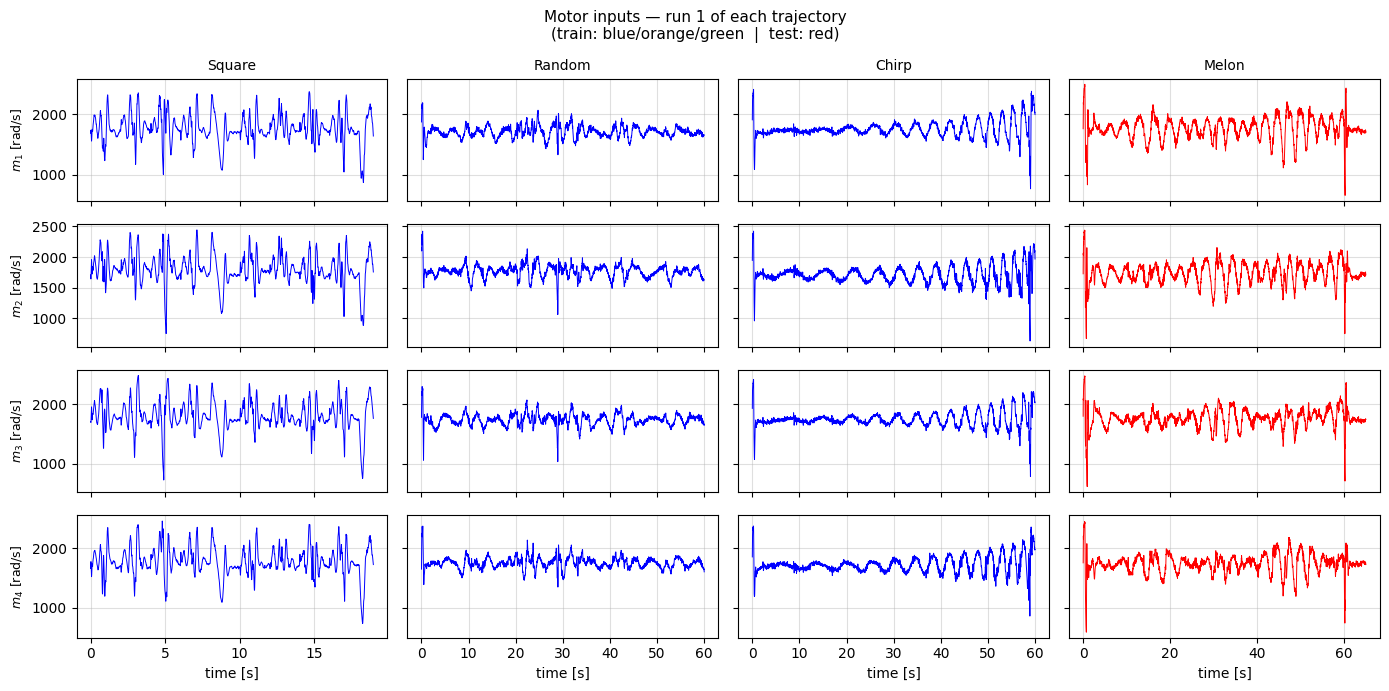

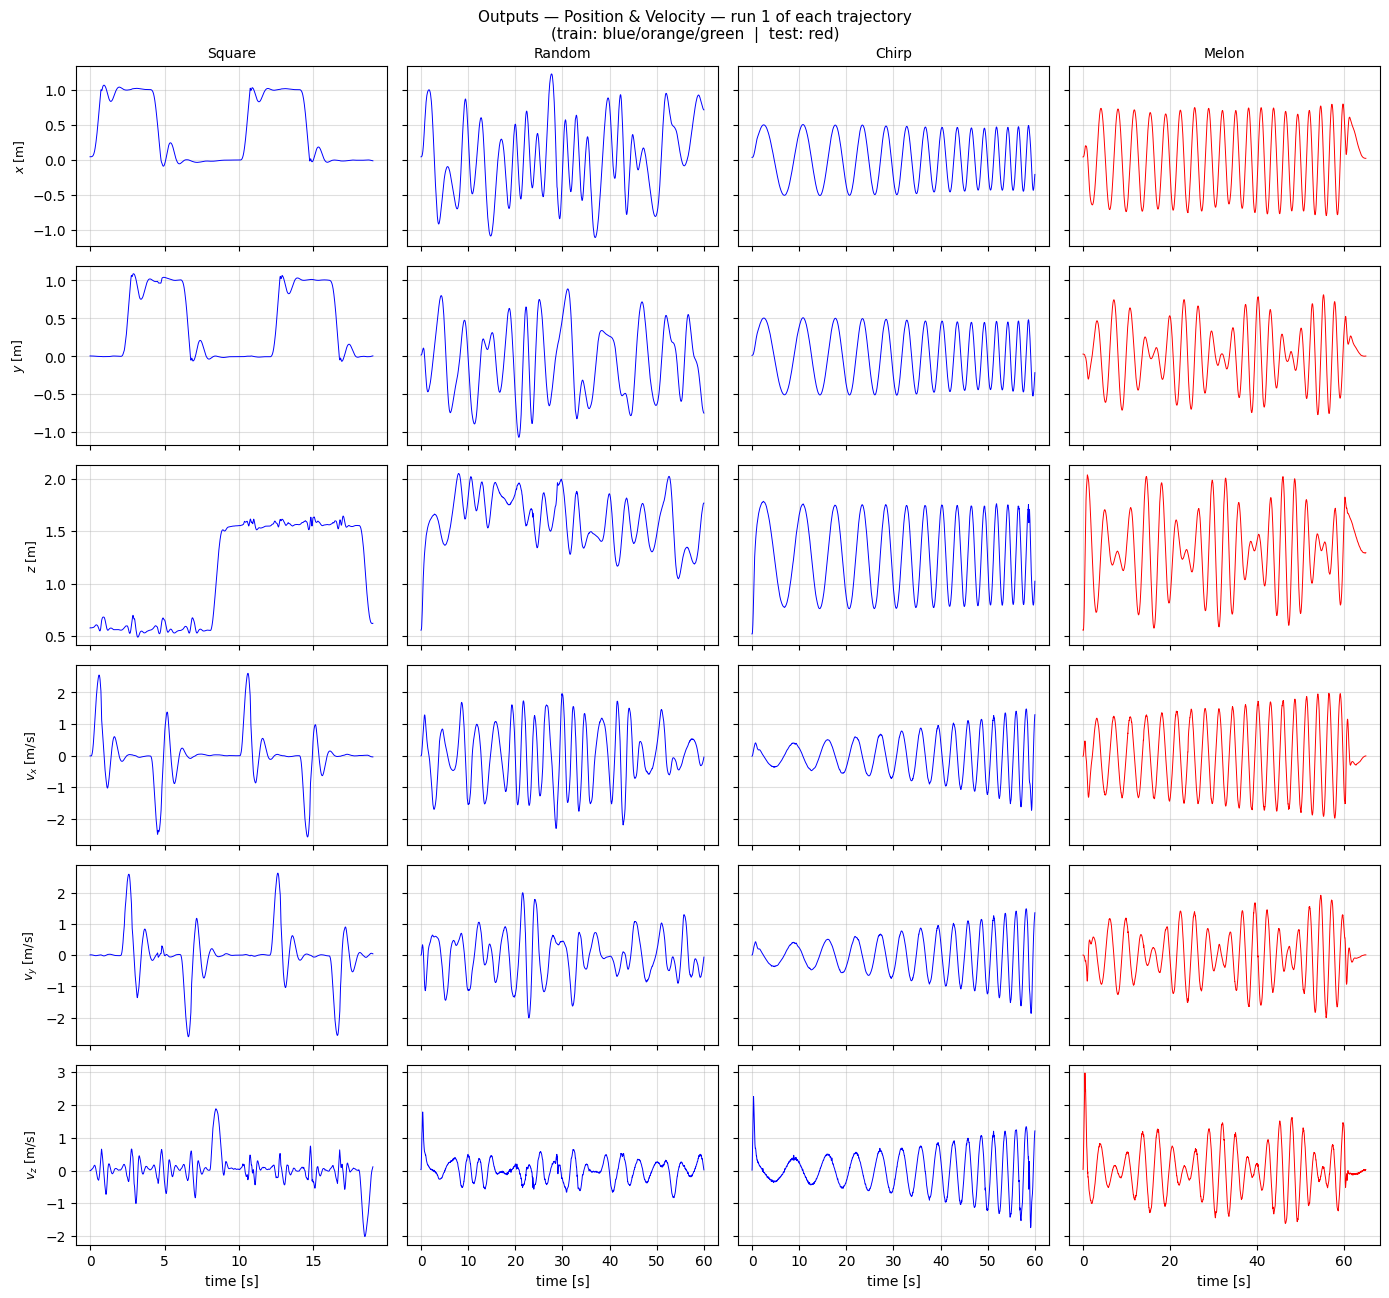

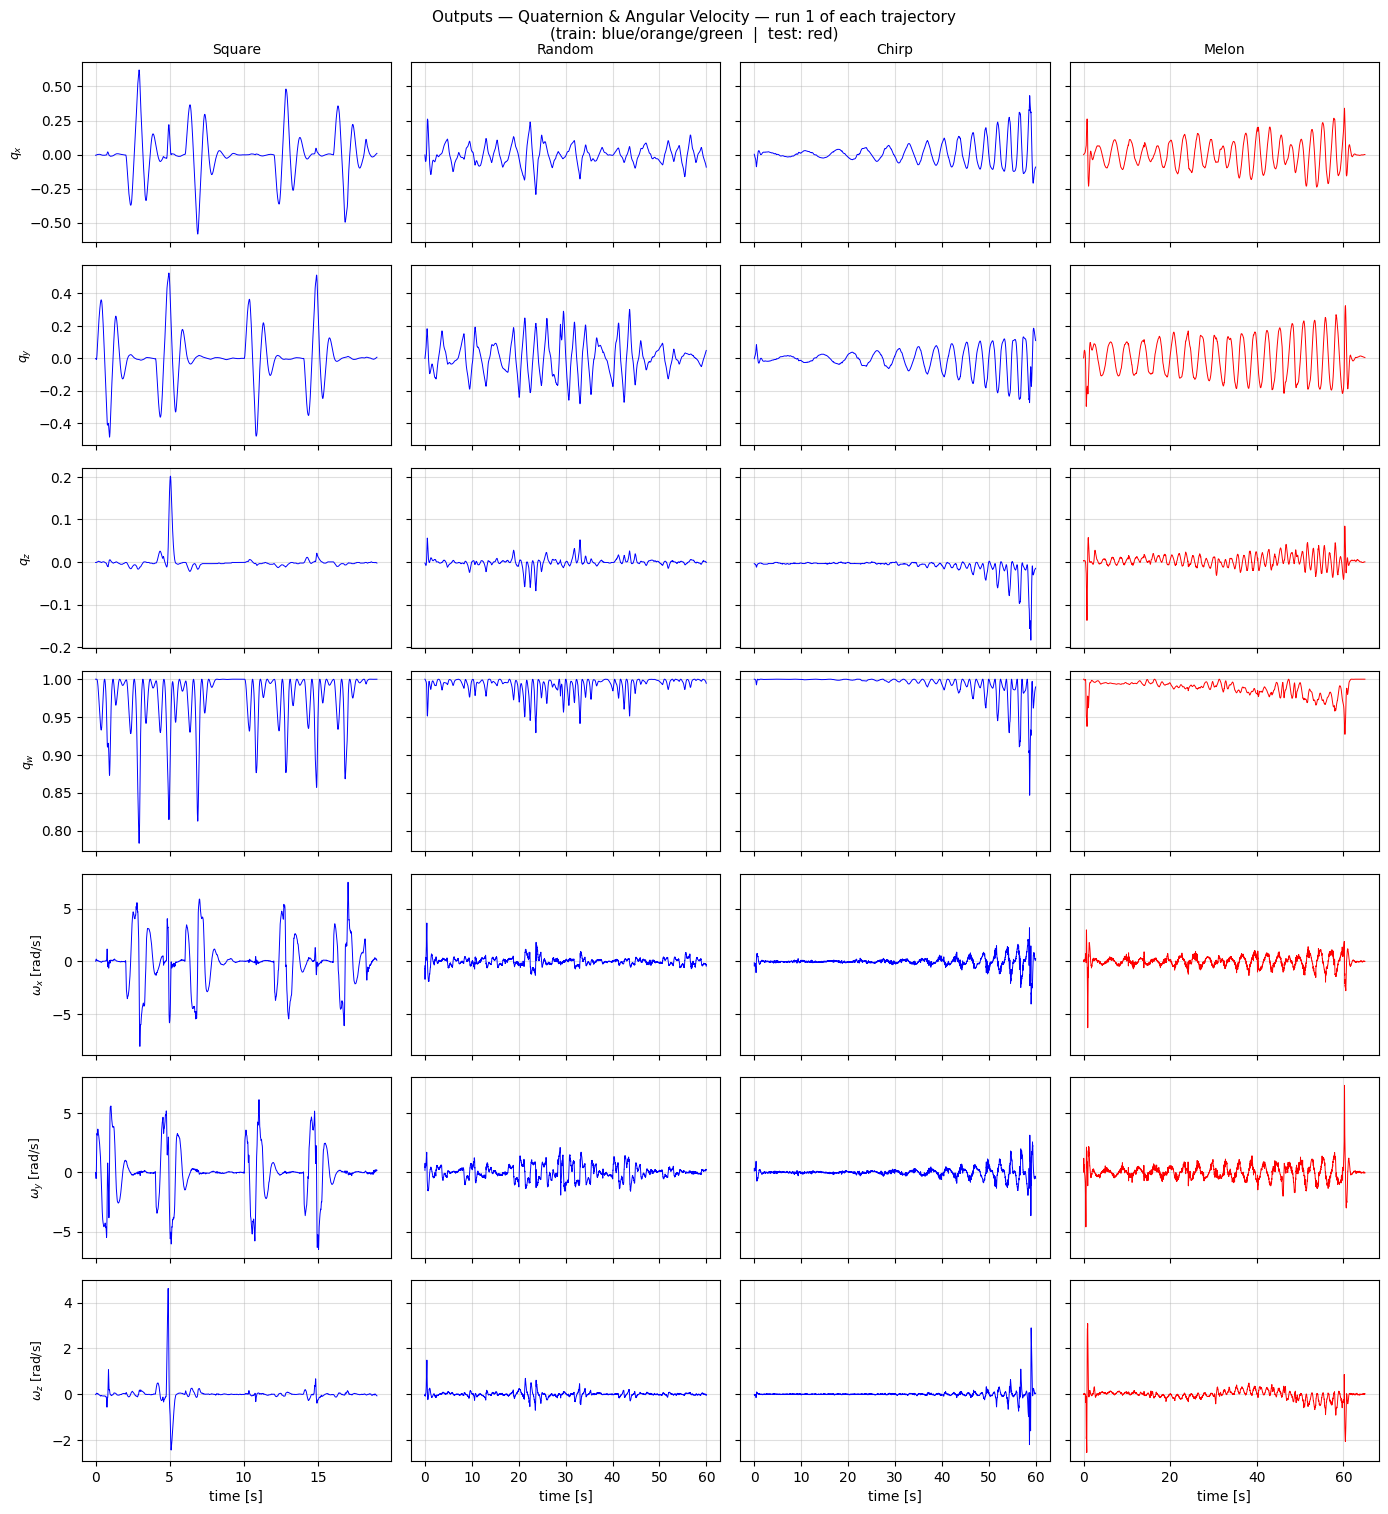

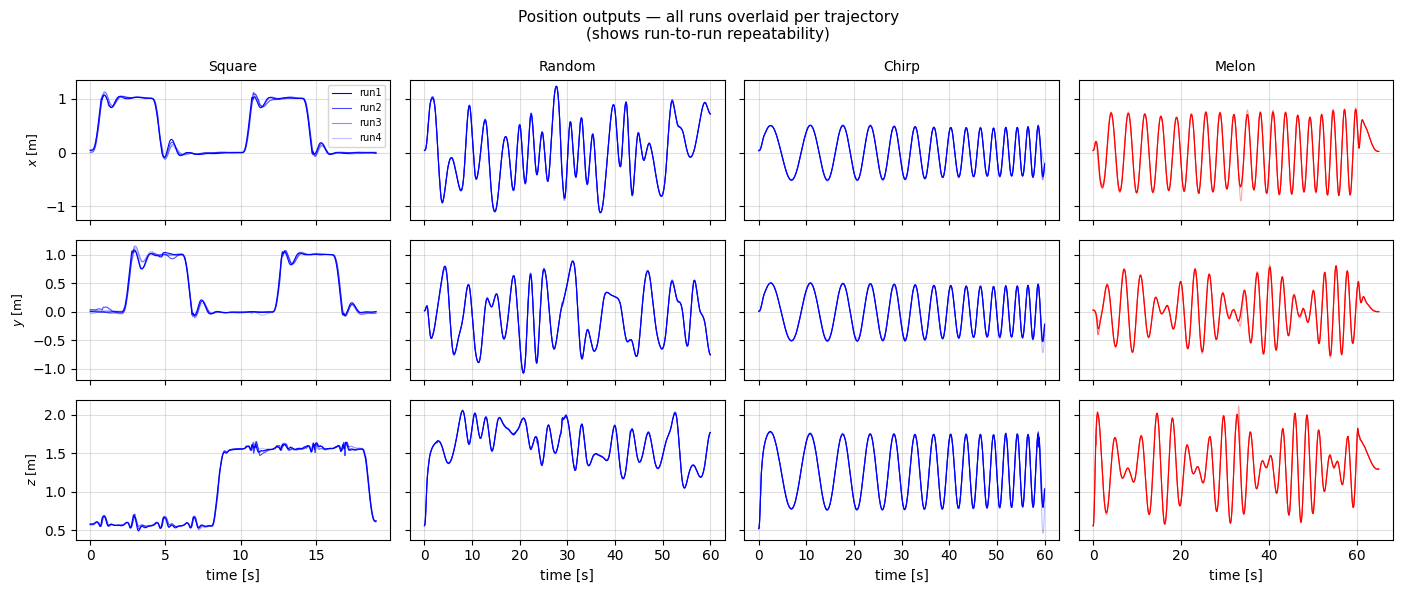

In [5]:
data_train, data_test = nlb.NanoDrone()

# train is a list of 9 Input_output_data (square/random/chirp x 3 runs)
# test  is a list of 3 Input_output_data (melon x 3 runs)

# train: 9 datasets  (square/random/chirp x run1/run2/run3)
# test:  3 datasets  (melon x run1/run2/run3)

sampling_time = data_train[0].sampling_time  # 0.01 s

# ── Signal definitions ─────────────────────────────────────────────────────
input_labels  = ['$m_1$ [rad/s]', '$m_2$ [rad/s]', '$m_3$ [rad/s]', '$m_4$ [rad/s]']
output_labels = ['$x$ [m]', '$y$ [m]', '$z$ [m]',
                 '$v_x$ [m/s]', '$v_y$ [m/s]', '$v_z$ [m/s]',
                 '$q_x$', '$q_y$', '$q_z$', '$q_w$',
                 '$\omega_x$ [rad/s]', '$\omega_y$ [rad/s]', '$\omega_z$ [rad/s]']

train_trajectories = ['square', 'random', 'chirp']
test_trajectories  = ['melon']

# Build lookup: name -> dataset
data_dict = {d.name: d for d in data_train + data_test}

# ── Figure 1: Inputs (motor speeds) ────────────────────────────────────────
# Show run1 of each trajectory (train + test), one row per motor
all_trajectories = train_trajectories + test_trajectories
colors = {'square': 'blue',
          'random': 'blue',
          'chirp':  'blue',
          'melon':  'red'}

nu = 4
fig1, axes1 = plt.subplots(nu, len(all_trajectories),
                           figsize=(14, 7), sharex='col', sharey='row')
fig1.suptitle('Motor inputs — run 1 of each trajectory\n'
              '(train: blue/orange/green  |  test: red)', fontsize=11)

for col_idx, traj in enumerate(all_trajectories):
    split  = 'test' if traj == 'melon' else 'train'
    key    = f'{split} {traj} run1'
    d      = data_dict[key]
    t      = np.arange(len(d.u)) * sampling_time
    color  = colors[traj]
    axes1[0, col_idx].set_title(traj.capitalize(), fontsize=10)
    for row_idx in range(nu):
        axes1[row_idx, col_idx].plot(t, d.u[:, row_idx], color=color, lw=0.7)
        axes1[row_idx, col_idx].grid(True, alpha=0.4)
    axes1[-1, col_idx].set_xlabel('time [s]')

for row_idx, lbl in enumerate(input_labels):
    axes1[row_idx, 0].set_ylabel(lbl, fontsize=9)

plt.tight_layout()
# plt.savefig('../figures/NanoDrone_inputs.jpg', dpi=300, bbox_inches='tight')
plt.show()

# ── Figure 2: Outputs (state vector) ───────────────────────────────────────
# Show run1 of each trajectory, one row per output channel
# Split into two figures to keep it readable (position+velocity | attitude)
output_groups = {
    'Position & Velocity': (range(6),  output_labels[:6]),
    'Quaternion & Angular Velocity': (range(6, 13), output_labels[6:]),
}

for group_name, (out_idx, out_lbls) in output_groups.items():
    out_idx = list(out_idx)
    ny_group = len(out_idx)
    fig, axes = plt.subplots(ny_group, len(all_trajectories),
                             figsize=(14, 2.2 * ny_group),
                             sharex='col', sharey='row')
    fig.suptitle(f'Outputs — {group_name} — run 1 of each trajectory\n'
                 f'(train: blue/orange/green  |  test: red)', fontsize=11)

    for col_idx, traj in enumerate(all_trajectories):
        split = 'test' if traj == 'melon' else 'train'
        key   = f'{split} {traj} run1'
        d     = data_dict[key]
        t     = np.arange(len(d.y)) * sampling_time
        color = colors[traj]
        axes[0, col_idx].set_title(traj.capitalize(), fontsize=10)
        for row_idx, oi in enumerate(out_idx):
            axes[row_idx, col_idx].plot(t, d.y[:, oi], color=color, lw=0.7)
            axes[row_idx, col_idx].grid(True, alpha=0.4)
        axes[-1, col_idx].set_xlabel('time [s]')

    for row_idx, lbl in enumerate(out_lbls):
        axes[row_idx, 0].set_ylabel(lbl, fontsize=9)

    plt.tight_layout()
    safe_name = group_name.replace(' ', '_').replace('&', 'and')
    # plt.savefig(f'../figures/NanoDrone_{safe_name}.jpg', dpi=300, bbox_inches='tight')
    plt.show()

# ── Figure 3: All 3 runs overlaid per trajectory (position only) ───────────
# Shows repeatability across runs
fig3, axes3 = plt.subplots(3, len(all_trajectories),
                            figsize=(14, 6), sharex='col', sharey='row')
fig3.suptitle('Position outputs — all runs overlaid per trajectory\n'
              '(shows run-to-run repeatability)', fontsize=11)

train_run_alphas = [1.0, 0.7, 0.45, 0.25]  # 4 runs for train trajectories
test_run_alphas  = [1.0, 0.6, 0.35]         # 3 runs for melon

for col_idx, traj in enumerate(all_trajectories):
    split      = 'test' if traj == 'melon' else 'train'
    color      = colors[traj]
    runs       = [1, 2, 3] if traj == 'melon' else [1, 2, 3, 4]
    run_alphas = test_run_alphas if traj == 'melon' else train_run_alphas
    axes3[0, col_idx].set_title(traj.capitalize(), fontsize=10)
    for run in runs:
        key = f'{split} {traj} run{run}'
        d   = data_dict[key]
        t   = np.arange(len(d.y)) * sampling_time
        for row_idx, oi in enumerate([0, 1, 2]):  # x, y, z
            axes3[row_idx, col_idx].plot(t, d.y[:, oi],
                                         color=color,
                                         alpha=run_alphas[run - 1],
                                         lw=0.8,
                                         label=f'run{run}')
        axes3[-1, col_idx].set_xlabel('time [s]')

for row_idx, lbl in enumerate(['$x$ [m]', '$y$ [m]', '$z$ [m]']):
    axes3[row_idx, 0].set_ylabel(lbl, fontsize=9)

axes3[0, 0].legend(fontsize=7, loc='upper right')
for ax in axes3.flat:
    ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig('../figures/NanoDrone_repeatability.jpg', dpi=300, bbox_inches='tight')
plt.show()